# Statistical Evaluation of Ancestry Tract Lengths Along a Chromosome

This notebook develops a framework for analysing **local ancestry** along a chromosome in an admixed population. A resident population contributes a fraction $f_r = 0.7$ of the genome and an invading population contributes $f_i = 0.3$, following a single pulse of admixture $t$ generations ago. Each chromosome carries consecutive segments coloured as either *resident* or *foreign* ancestry. The analysis asks three questions: how probable is a segment of the observed length under the null model, what does the per-position probability landscape look like across many chromosomes, and which positions carry anomalously long segments after proper multiple-testing correction.

## Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from scipy.stats import chi2
import seaborn as sns

# Reproducibility
np.random.seed(42)

from vscodenb import set_vscode_theme, vscode_theme
set_vscode_theme(style='ticks')
plt.set_cmap('tab10')
sns.set_palette('tab10')

<Figure size 500x370 with 0 Axes>

## Background and Model

We model a single pulse of admixture at generation $t$ in the past, in which a fraction $f_i = 0.3$ of the population's ancestry derives from an invading population and $f_r = 0.7$ from the resident population. After the admixture event, recombination progressively breaks down the long ancestry tracts inherited from each parental population. Under this model, tract lengths in genetic distance follow an exponential distribution whose rate depends on the ancestry class:

$$G \sim \text{Exponential}(\lambda), \quad \lambda = (1-f) \cdot t$$

where $f$ is the frequency of the ancestry in question and $t$ is generations since admixture. The rate $(1-f)$ reflects the fact that a tract of ancestry $f$ ends when recombination places it against the *other* ancestry's background, which occurs with probability $1-f$ per recombination event. The mean tract length is $\mathbb{E}[G] = 1/((1-f) \cdot t)$ Morgans, or approximately $1/(r \cdot (1-f) \cdot t)$ base pairs after converting through the local recombination rate $r$.

For a chromosome with loci indexed $i = 0, \ldots, n-1$, we define the probability matrix $P[i,j] = \exp(-(1-f) \cdot |g_j - g_i| \cdot t)$, where $g_i$ is the genetic map position of locus $i$. The upper triangle ($j > i$) uses $f = f_r$ (resident ancestry) and the lower triangle uses $f = f_i$ (invader ancestry). This matrix simultaneously serves as the survival function of the null distribution: a small value of $P[i,j]$ indicates that a tract spanning positions $i$ to $j$ is longer than expected under the null — no separate test statistic is needed.

## Genetic Map

A genetic map provides cumulative recombination distance (Morgans) as a function of physical position (bp). We use a synthetic map with recombination rate $r \approx 10^{-6}$ M/bp (roughly 10× the typical human average) and $t = 100$ generations. This gives mean tract lengths of about 143 kb (resident) and 333 kb (invader), which fit comfortably within the 5 Mb chromosome and produce multi-segment chromosomes suitable for illustration. The product $r \cdot t$ determines segment lengths, so increasing $t$ at lower $r$ gives identical distributions — the human genome average ($r \approx 10^{-8}$ M/bp) with $t = 1000$ generations would yield similar results.

In [ ]:
# ── Simulation parameters ────────────────────────────────────────────────────
CHROM_LENGTH  = 5_000_000   # bp
N_MAP_POINTS  = 500
N_CHROMOSOMES = 10
T             = 100          # generations since admixture
F_RES         = 0.7          # resident ancestry frequency
F_INV         = 0.3          # invader  ancestry frequency
N_EVAL        = 3000         # evaluation positions for per-position plots
ALPHA         = 0.05         # significance level

colors = {name: color for name, color in zip(['resident', 'foreign', 'both', 'joint'], ['C0', 'C3', 'C2', 'C1'])}

# Rate parameter: λ = (1-f)·t — a tract ends when recombination hits the other background
ancestry_rate = {"resident": (1 - F_RES) * T, "foreign": (1 - F_INV) * T}

from lai_significance import (
    test_segments, simulate_chromosome, inject_segment,
    make_phys_to_gen, bh_correction,
)

# ── Build synthetic genetic map ──────────────────────────────────────────────
rng_map       = np.random.default_rng(seed=42)
physical_map  = np.linspace(0, CHROM_LENGTH, N_MAP_POINTS)   # bp
rate_per_bp   = 1e-7 * (1 + 0.5 * rng_map.random(N_MAP_POINTS))  # Morgans/bp, with spatial variation

#rate_per_bp *= 10 

# ------------------------------------------------------------
# # Add a large-scale wave pattern to the recombination rate, to make it more realistic
# wave = np.sin(physical_map/100000)/2 + 0.5
# rate_per_bp *= wave * 10
# ------------------------------------------------------------

genetic_map   = np.cumsum(rate_per_bp * np.diff(physical_map, prepend=0))  # cumulative Morgans

r = genetic_map[-1] / CHROM_LENGTH    # mean recombination rate

# Interpolation functions
phys_to_gen = make_phys_to_gen(physical_map, genetic_map)
gen_to_phys = interp1d(genetic_map, physical_map,
                       bounds_error=False, fill_value='extrapolate')

print(f"Chromosome length : {CHROM_LENGTH/1e6:.1f} Mb")
print(f"Total map length  : {genetic_map[-1]*100:.2f} cM")
print(f"Mean rate r       : {r:.3e} Morgans/bp")
print()
for label, f in [('Resident', F_RES), ('Invader', F_INV)]:
    lam = (1 - f) * T
    mean_bp = 1.0 / (r * lam)
    print(f"{label}: λ = (1-{f})·{T} = {lam:.0f}  |  "
          f"E[length] = {mean_bp/1e3:.1f} kb  |  "
          f"E[genetic length] = {1/lam*100:.3f} cM")

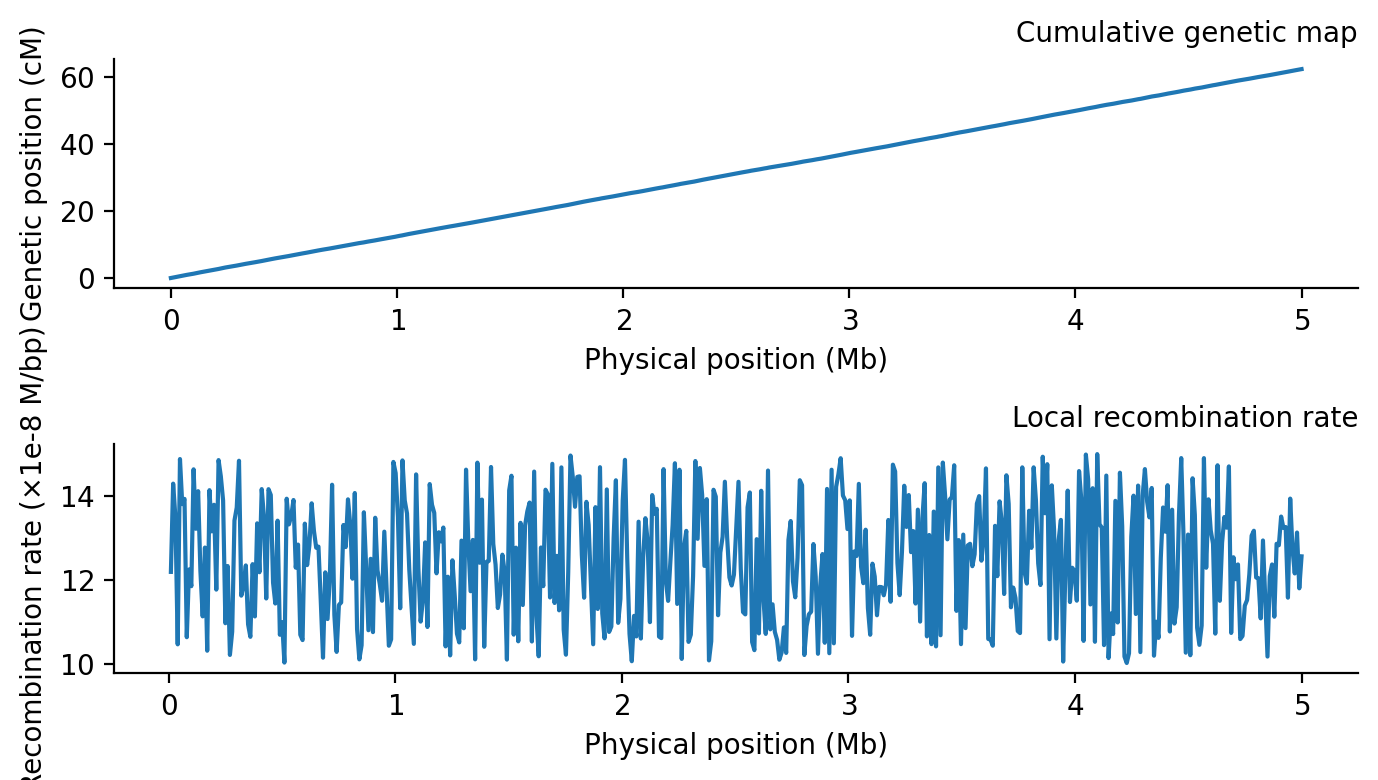

In [38]:
fig, ax = plt.subplots(2, 1, figsize=(7, 4))

ax[0].plot(physical_map/1e6, genetic_map*100)
ax[0].set_xlabel('Physical position (Mb)')
ax[0].set_ylabel('Genetic position (cM)')
ax[0].set_title('Cumulative genetic map')

local_rate = np.diff(genetic_map) / np.diff(physical_map)
ax[1].plot(physical_map[1:]/1e6, local_rate * 1e8)
ax[1].set_xlabel('Physical position (Mb)')
ax[1].set_ylabel('Recombination rate (×1e-8 M/bp)')
ax[1].set_title('Local recombination rate')

plt.tight_layout()
plt.show()


## Ancestry Segment Length Probability Matrix

The matrix $P \in \mathbb{R}^{n \times n}$ is computed from the signed genetic distance $G[i,j] = \text{gpos}[j] - \text{gpos}[i]$, a frequency mask $F[i,j]$ that assigns $(1-f_r)$ when $G[i,j] > 0$, $(1-f_i)$ when $G[i,j] < 0$, and 1 on the diagonal, and the exponential $P[i,j] = \exp(-F[i,j] \cdot |G[i,j]| \cdot t)$. The three panels below show how the matrix evolves with admixture time $t$: at early times tracts are long and probabilities decay slowly away from the diagonal, while at later times the off-diagonal entries approach zero as tracts shorten.

In [ ]:
def ancestry_segment_probability_matrix(genetic_positions, t, f_upper, f_lower):
    """
    Compute P[i,j] = exp(-(1-f) * |g(i,j)| * t) where:
      g(i,j) = gpos[j] - gpos[i]  (signed genetic distance)
      f = f_upper if j > i  (upper triangle: resident ancestry)
        = f_lower if j < i  (lower triangle: invader ancestry)
        = 1       if i == j (diagonal)

    Parameters
    ----------
    genetic_positions : array, shape (n,)
        Cumulative genetic map positions (Morgans).
    t : float
        Generations since admixture.
    f_upper, f_lower : float
        Ancestry frequencies for upper and lower triangles.

    Returns
    -------
    P : ndarray, shape (n, n)
    """
    gpos = np.asarray(genetic_positions, dtype=float)
    G    = gpos[np.newaxis, :] - gpos[:, np.newaxis]   # G[i,j] = gpos[j]-gpos[i]
    F    = np.where(G > 0, 1 - f_upper, np.where(G < 0, 1 - f_lower, 1.0))
    return np.exp(-F * np.abs(G) * t)

In [ ]:
n_sub     = 300
sub_idx   = np.linspace(0, N_MAP_POINTS - 1, n_sub, dtype=int)
gpos_sub  = genetic_map[sub_idx]
phys_sub  = physical_map[sub_idx]
t_values  = [10, 50, 200]

fig, axes = plt.subplots(1, 3, figsize=(10, 4))

for ax, t_val in zip(axes, t_values):
    P  = ancestry_segment_probability_matrix(gpos_sub, t_val, F_RES, F_INV)
    mb = phys_sub / 1e6
    im = ax.imshow(P, origin='upper', aspect='auto', cmap='viridis',
                   vmin=0, vmax=1,
                   extent=[mb[0], mb[-1], mb[-1], mb[0]])
    ax.text(0.97, 0.97, f'Invader  f={F_INV}', transform=ax.transAxes,
            color='white', fontsize=8, ha='right', va='top')
    ax.text(0.03, 0.03, f'Resident  f={F_RES}', transform=ax.transAxes,
            color='white', fontsize=8, ha='left', va='bottom')
    ax.set_title(f't = {t_val} generations')
    ax.set_xlabel('Locus j  (Mb)')

axes[0].set_ylabel('Locus i  (Mb)')
for ax in axes[1:]:
    ax.set_yticklabels([])

from mpl_toolkits.axes_grid1 import make_axes_locatable

divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)


cb = fig.colorbar(im, cax=cax)
cb.set_label('P[i, j]')

fig.suptitle(
    r'Ancestry Segment Probability Matrix   $P[i,j] = \exp(-(1\!-\!f) \cdot g(i,j) \cdot t)$')

plt.tight_layout()
plt.savefig('ancestry_segment_matrix.png', dpi=150,
            bbox_inches='tight')
plt.show()

## Chromosome Simulation

Under the admixture model, ancestry breakpoints occur as a Poisson process in genetic distance. Segments of a given ancestry therefore have genetic lengths $G \sim \text{Exp}(\lambda)$ with $\lambda = (1-f) \cdot t$. The simulation places breakpoints in genetic space and converts to physical coordinates via the genetic map, ensuring that the null model and the p-value computation use the same coordinate system. Resident tracts have rate $(1-f_r) \cdot t$ and foreign tracts have rate $(1-f_i) \cdot t$.

In [ ]:
rng    = np.random.default_rng(7)
chroms = [simulate_chromosome(CHROM_LENGTH, gen_to_phys, phys_to_gen,
                              ancestry_rate, rng)
          for _ in range(N_CHROMOSOMES)]

# Summary statistics
print(f"{'Chr':>4}  {'#res':>5}  {'res bp':>9}  {'#inv':>5}  {'inv bp':>9}  {'total':>9}")
print('-' * 55)
for i, ch in enumerate(chroms):
    nr  = sum(1 for s in ch if s[2] == 'resident')
    ni  = sum(1 for s in ch if s[2] == 'foreign')
    rbp = sum(e-s for s,e,a in ch if a == 'resident')
    ibp = sum(e-s for s,e,a in ch if a == 'foreign')
    print(f"{i+1:>4}  {nr:>5}  {rbp/1e3:>8.0f}k  {ni:>5}  {ibp/1e3:>8.0f}k  "
          f"{(rbp+ibp)/1e3:>8.0f}k")

In [ ]:
# for c in range(N_CHROMOSOMES-1):
#     chroms[c] = inject_segment(chroms[c], 
#                                2_000_000-c*100000*abs(np.random.random(1).item()),
#                                2_000_000+c*100000*abs(np.random.random(1).item()), 'foreign')  

mean_res = 1 / (r * (1 - F_RES) * T)
mean_inv = 1 / (r * (1 - F_INV) * T)
mean_res, mean_inv

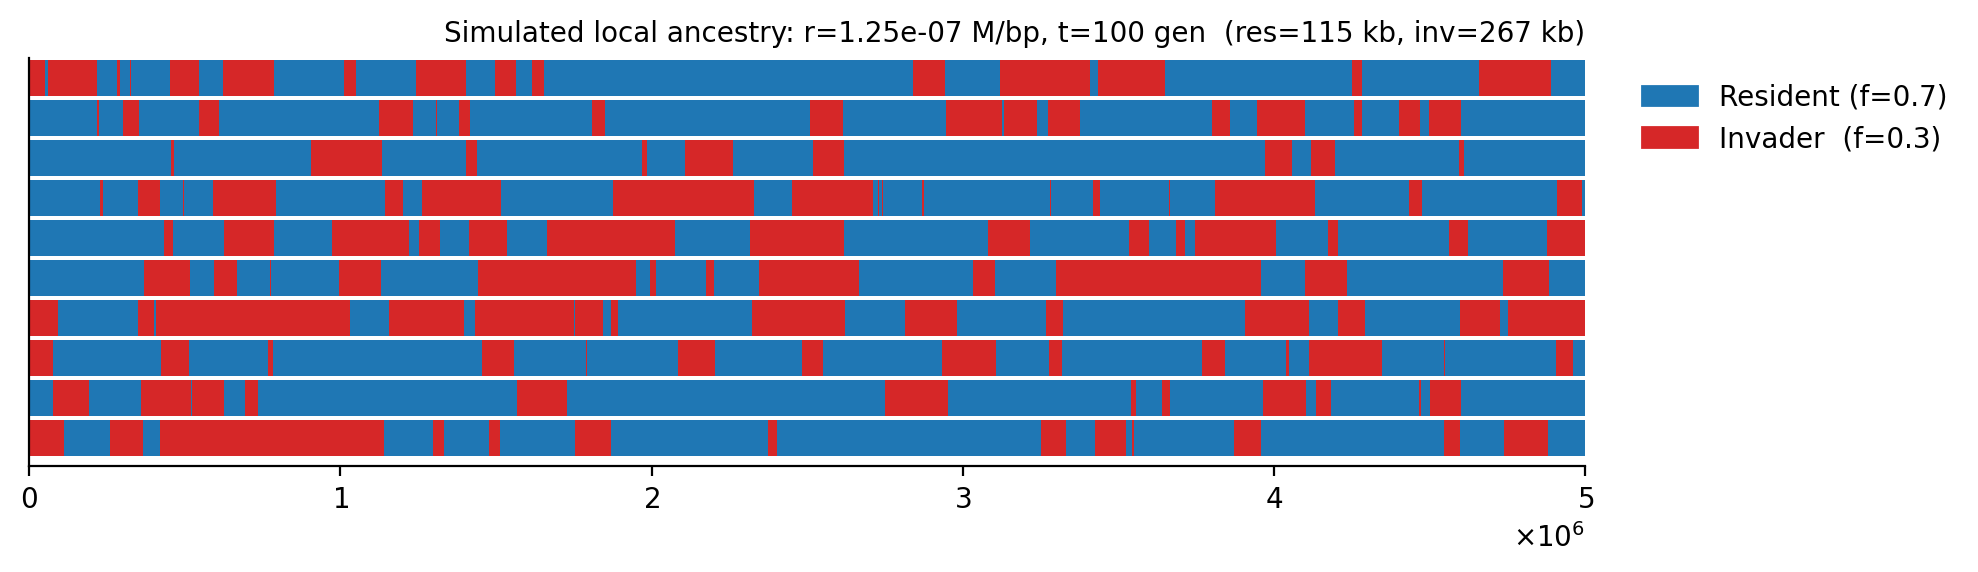

In [43]:
# ── Plot chromosome diagram ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 3))

for i, ch in enumerate(chroms):
    for (s, e, anc) in ch:
        ax.barh(i-0.5, e-s, left=s, height=0.9,
                color=colors[anc], linewidth=0)

ax.set_xlim(0, CHROM_LENGTH)
ax.set_ylim(-1.2, N_CHROMOSOMES - 1)
ax.set_yticks([])

patches = [mpatches.Patch(color=colors['resident'], label=f'Resident (f={F_RES})'),
           mpatches.Patch(color=colors['foreign'],  label=f'Invader  (f={F_INV})')]
ax.legend(handles=patches, bbox_to_anchor=(1.02, 1))
ax.set_title(
    f'Simulated local ancestry: r={r:.2e} M/bp, t={T} gen  (res={mean_res/1e3:.0f} kb, inv={mean_inv/1e3:.0f} kb)')

plt.tight_layout()
plt.savefig('chromosome_diagram.png', dpi=150, bbox_inches='tight')
plt.show()


## Per-Position Mean Probability

For each evaluation position $x$ along the chromosome, we compute $\bar{P}_f(x) = |C_f(x)|^{-1} \sum_{c \in C_f(x)} \exp(-(1-f) \cdot g_c(x) \cdot t)$, where $C_f(x)$ is the set of chromosomes carrying ancestry $f$ at position $x$ and $g_c(x)$ is the genetic length of the segment covering $x$ on chromosome $c$. This average probability summarises how typical the observed segment lengths are at each position, aggregating across chromosomes by averaging rather than multiplying. Significance testing of individual segments is addressed in the next section.

In [ ]:
eval_pos = np.linspace(0, CHROM_LENGTH, N_EVAL)
prob_sum = {a: np.zeros(N_EVAL) for a in ('resident', 'foreign', 'both')}
count    = {a: np.zeros(N_EVAL) for a in ('resident', 'foreign', 'both')}
for ch in chroms:
    for (start, end, anc) in ch:
        lam  = ancestry_rate[anc]
        g    = float(phys_to_gen(end) - phys_to_gen(start))   # Morgans
        prob = np.exp(-lam * g)
        mask = (eval_pos >= start) & (eval_pos < end)
        prob_sum[anc][mask] += prob
        count[anc][mask]    += 1
        prob_sum['both'][mask] += prob
        count['both'][mask] += 1
mean_prob = { a: np.where(count[a] > 0, -np.log10(prob_sum[a] / count[a]), np.nan) for a in ('resident', 'foreign', 'both') }

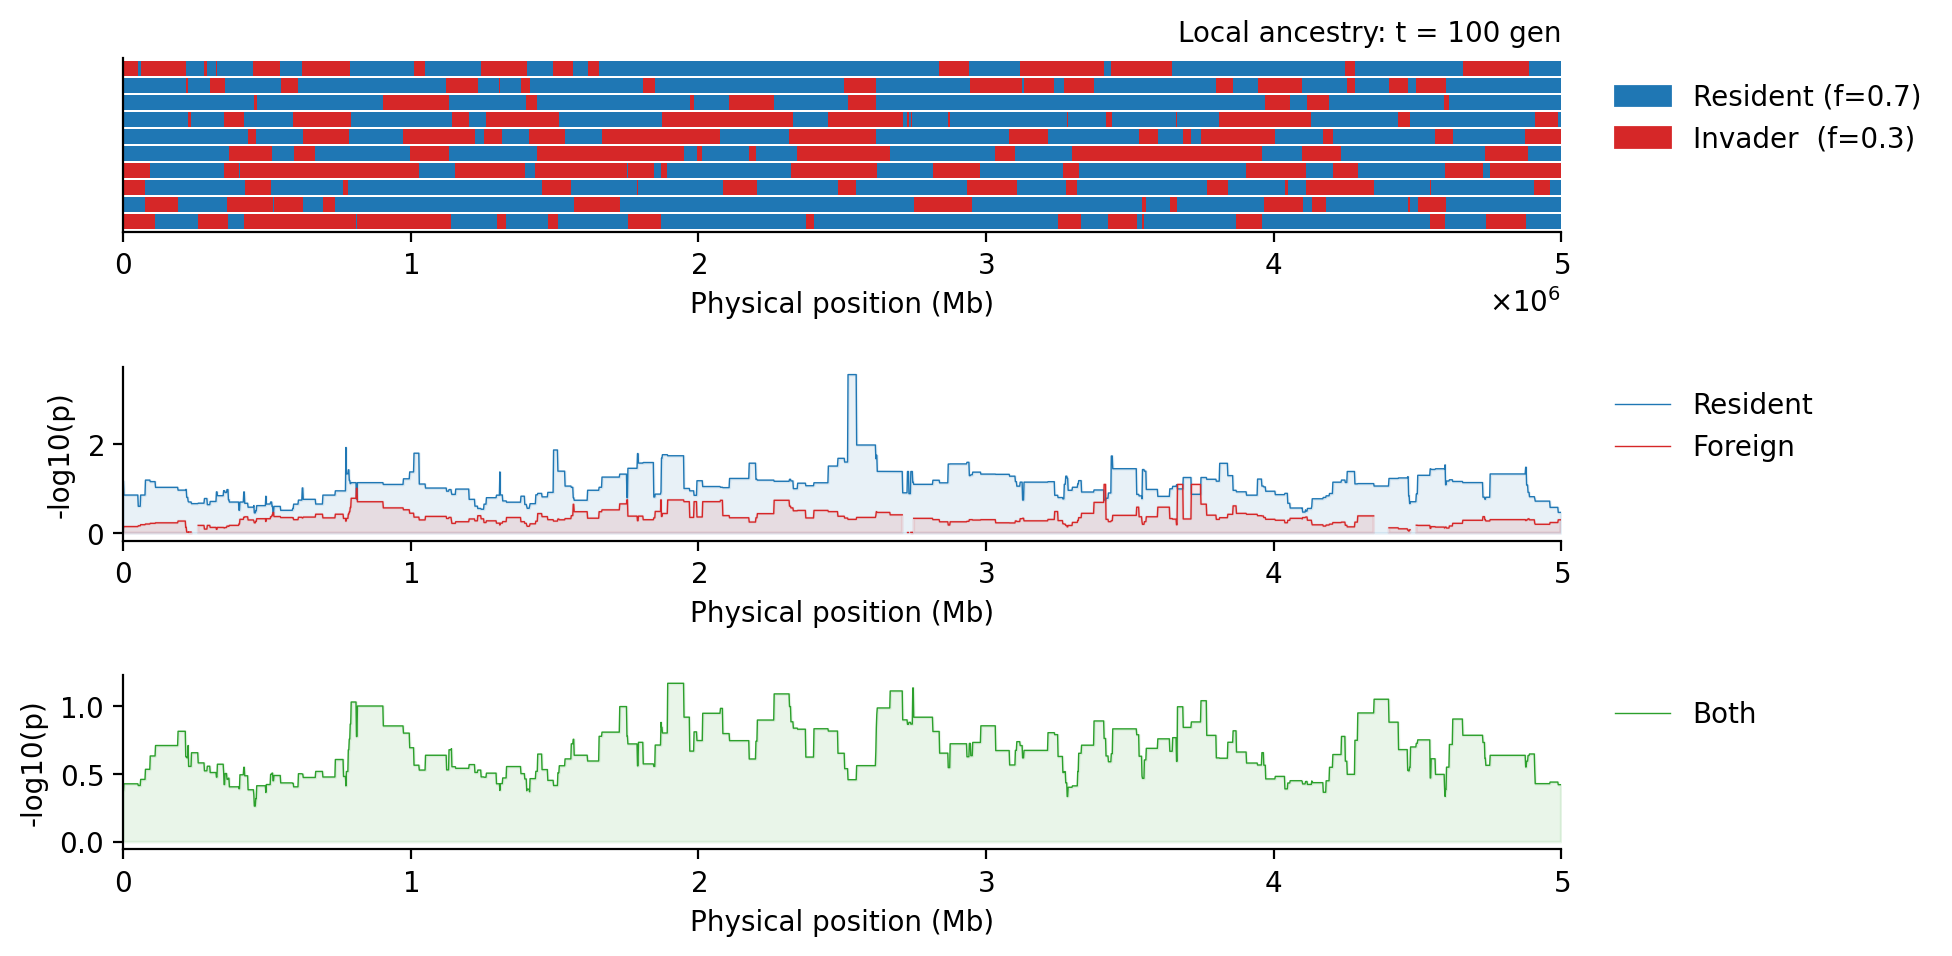

In [45]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 5))

mb  = eval_pos / 1e6

for i, ch in enumerate(chroms):
    for (s, e, anc) in ch:
        ax1.barh(i, e-s, left=s, height=0.9, color=colors[anc], linewidth=0)
ax1.set_xlim(0, CHROM_LENGTH); 
ax1.set_ylim(-0.6, N_CHROMOSOMES - 0.4)
ax1.set_yticks([])
patches = [mpatches.Patch(color=colors['resident'], label=f'Resident (f={F_RES})'),
           mpatches.Patch(color=colors['foreign'],  label=f'Invader  (f={F_INV})')]
ax1.legend(handles=patches, bbox_to_anchor=(1.02, 1))
ax1.set_title(f'Local ancestry: t = {T} gen')
ax1.set_xlabel('Physical position (Mb)')

for anc in ('resident', 'foreign'):
    ax2.plot(mb, mean_prob[anc], color=colors[anc], lw=0.5, label=f'{anc.capitalize()}')
    ax2.fill_between(mb, mean_prob[anc], alpha=0.10, color=colors[anc])

ax2.set_xlim(0, CHROM_LENGTH/1e6)
ax2.set_xlabel('Physical position (Mb)')
ax2.set_ylabel('-log10(p)')
ax2.legend(bbox_to_anchor=(1.02, 1))

anc='both'
ax3.plot(mb, mean_prob[anc], color=colors[anc], lw=0.5, label=f'{anc.capitalize()}')
ax3.fill_between(mb, mean_prob[anc], alpha=0.10, color=colors[anc])
ax3.set_ylabel('-log10(p)')
ax3.set_xlim(0, CHROM_LENGTH/1e6) 
ax3.set_xlabel('Physical position (Mb)')
ax3.legend(bbox_to_anchor=(1.02, 1))

plt.tight_layout(pad=1.5)
plt.show()


---

## Significance Testing

At each evaluation position $x$, we observe the ancestry segment that covers that position and ask how surprising its length is under the null model.

**The inspection paradox.** Under the null, segment genetic lengths are $G \sim \text{Exp}(\lambda)$ with $\lambda = (1-f) \cdot t$. A naive p-value would use the exponential survival function $p_\text{naive} = e^{-\lambda g}$, but this is wrong. The segment covering a fixed position is not a random draw from the population of segments — it is sampled with probability proportional to its length, because longer segments cover more positions. This is the classical inspection paradox (or length-biased sampling). Because breakpoints form a Poisson process in genetic distance, the distance from the position to the next breakpoint (residual life) and the distance from the previous breakpoint to the position (age) are each $\text{Exp}(\lambda)$ and independent by the memoryless property. The total segment length is therefore $\text{Gamma}(2, 1/\lambda)$, and the correct p-value is the Gamma(2) survival function:

$$p(g) = (1 + \lambda g)\, e^{-\lambda g}$$

This is always larger than $e^{-\lambda g}$, reflecting the fact that observing a long segment at a fixed position is less surprising than drawing one at random — you are more likely to land in a long segment precisely because it is long. Without this correction, the false positive rate is approximately 20% instead of the nominal 5%.

**Min-p across chromosomes.** At each position we have up to $k$ chromosomes carrying a given ancestry. We take the minimum p-value (corresponding to the longest segment) and correct for the fact that the minimum of $k$ independent $\text{Uniform}[0,1]$ variables follows $\text{Beta}(1,k)$: $p_\text{corr}(x) = 1 - (1 - p_\text{min})^k$. Without this correction the test would be anti-conservative, since the minimum of several uniform values concentrates near zero.

**Multiple testing.** We evaluate significance at $N = 3{,}000$ positions, so naively declaring every position with $p < 0.05$ significant would produce $\sim 150$ false positives. The Bonferroni correction controls the family-wise error rate by requiring $p < \alpha/N$, which is strict — it treats every test as an independent opportunity for error. The Benjamini–Hochberg (BH) procedure instead controls the false discovery rate, the expected fraction of declared discoveries that are false positives. It works by sorting all $N$ p-values, finding the largest rank $k^*$ satisfying $p_{(k^*)} \leq k^* \alpha / N$, and declaring all positions with rank $\leq k^*$ significant. When many true signals cluster at the low end of the sorted list, BH adapts and sets a more generous effective threshold, recovering more true discoveries than Bonferroni while still bounding the false discovery proportion at $\alpha$.

**Fisher joint test across ancestries.** To detect positions where both ancestries simultaneously carry anomalously long tracts, we combine the two per-ancestry min-p values using Fisher's method: $X^2 = -2(\ln p_r + \ln p_i) \sim \chi^2(4)$ under the null. Each $-2\ln p$ is $\chi^2(2)$ when $p$ is uniform, and their sum is $\chi^2(4)$ by independence. This test is sensitive to positions where both ancestry classes are unusual, not just one.

In [ ]:
# ── Per-position p-values ─────────────────────────────────────────────────────
results = test_segments(chroms, eval_pos, phys_to_gen, ancestry_rate, alpha=ALPHA)

pval_matrix = results["pval_matrix"]
pval        = results["min_p"]
pval_bonf   = results["min_p_bonf"]
pval_bh     = results["min_p_bh"]
fp          = results["fisher_joint"]
fp_bh       = results["fisher_joint_bh"]

# ── Summary ──────────────────────────────────────────────────────────────────
bonf_threshold_raw = ALPHA / N_EVAL
print(f"Bonferroni threshold (raw p < {bonf_threshold_raw:.2e})")
print()
print(f"  {'':8s}  {'Raw':>12s}  {'Bonferroni':>12s}  {'BH-FDR':>12s}")
print(f"  {'':8s}  {'(p < α)':>12s}  {'(FWER < α)':>12s}  {'(FDR < α)':>12s}")
print('  ' + '-' * 52)
for a in ('resident', 'foreign'):
    n_raw  = int(np.nansum(pval[a] < ALPHA))
    n_bonf = int(np.nansum(pval_bonf[a] < ALPHA))
    n_bh   = int(np.nansum(pval_bh[a]   < ALPHA))
    print(f"  {a:8s}  {n_raw:>12d}  {n_bonf:>12d}  {n_bh:>12d}")
n_raw_j  = int(np.nansum(fp < ALPHA))
n_bh_j   = int(np.nansum(fp_bh < ALPHA))
print(f"  {'joint':8s}  {n_raw_j:>12d}  {'—':>12s}  {n_bh_j:>12d}")
print()
print("Note: Raw > BH-FDR > Bonferroni — corrections can only remove significance, never add it.")

**Fisher combined test across chromosomes.** The min-p test uses only the single longest segment at each position. A natural extension is to combine evidence from all $k$ chromosomes carrying a given ancestry using Fisher's method: $F_a(x) = -2 \sum_{c=1}^{k} \ln p_{a,c}(x)$, where each $p_{a,c}(x)$ is the Gamma-corrected p-value on chromosome $c$. Under the null, each $-2\ln p \sim \chi^2(2)$ and their sum $F_a(x) \sim \chi^2(2k)$. In this simulation the chromosomes are drawn independently, so the exact $\chi^2(2k)$ null applies; in real data, chromosomes in a sample share genealogical history through the coalescent, which would require an effective sample size correction to account for the correlation. This test is more powerful than min-p when multiple chromosomes carry moderately long segments at the same position — a pattern expected under selection that affects many lineages simultaneously without producing a single extreme outlier.

In [ ]:
# ── Fisher combined test across chromosomes ──────────────────────────────────
pval_fisher_combined = results["fisher_combined"]
pval_fisher_combined_bh = results["fisher_combined_bh"]

# Summary
eps = 1e-300
print("Fisher combined test (all chromosomes):")
print(f"  {'':8s}  {'Raw':>12s}  {'BH-FDR':>12s}")
print(f"  {'':8s}  {'(p < α)':>12s}  {'(FDR < α)':>12s}")
print('  ' + '-' * 36)
for anc in ('resident', 'foreign'):
    n_raw = int(np.nansum(pval_fisher_combined[anc] < ALPHA))
    n_bh  = int(np.nansum(pval_fisher_combined_bh[anc] < ALPHA))
    print(f"  {anc:8s}  {n_raw:>12d}  {n_bh:>12d}")
print()
for anc in ('resident', 'foreign'):
    p = pval_fisher_combined[anc]
    valid = ~np.isnan(p)
    print(f"  {anc:8s}:  min p = {np.min(p[valid]):.2e},  "
          f"max -log10(p) = {-np.log10(max(np.min(p[valid]), eps)):.1f}")

The plot below has five panels sharing the same 5 Mb x-axis. Panel 1 shows the simulated ancestry segments across all 10 chromosomes for reference. Panel 2 plots the raw min-p values on a $-\log_{10}$ scale, with the Gamma(2) and Beta(1,k) corrections applied; the dotted line marks $\alpha = 0.05$ and the dashed line the Bonferroni threshold $\alpha/N$. Panel 3 shows the same p-values after BH-FDR adjustment, with coloured dots marking positions significant at FDR < 0.05. Panel 4 displays the Fisher joint test (BH-adjusted), highlighting positions where both ancestries are simultaneously anomalous. Panel 5 shows the Fisher combined test across chromosomes (BH-adjusted), which pools evidence from all chromosomes via $\chi^2(2k)$ and is sensitive to positions where many chromosomes carry moderately long segments even if none is individually extreme.

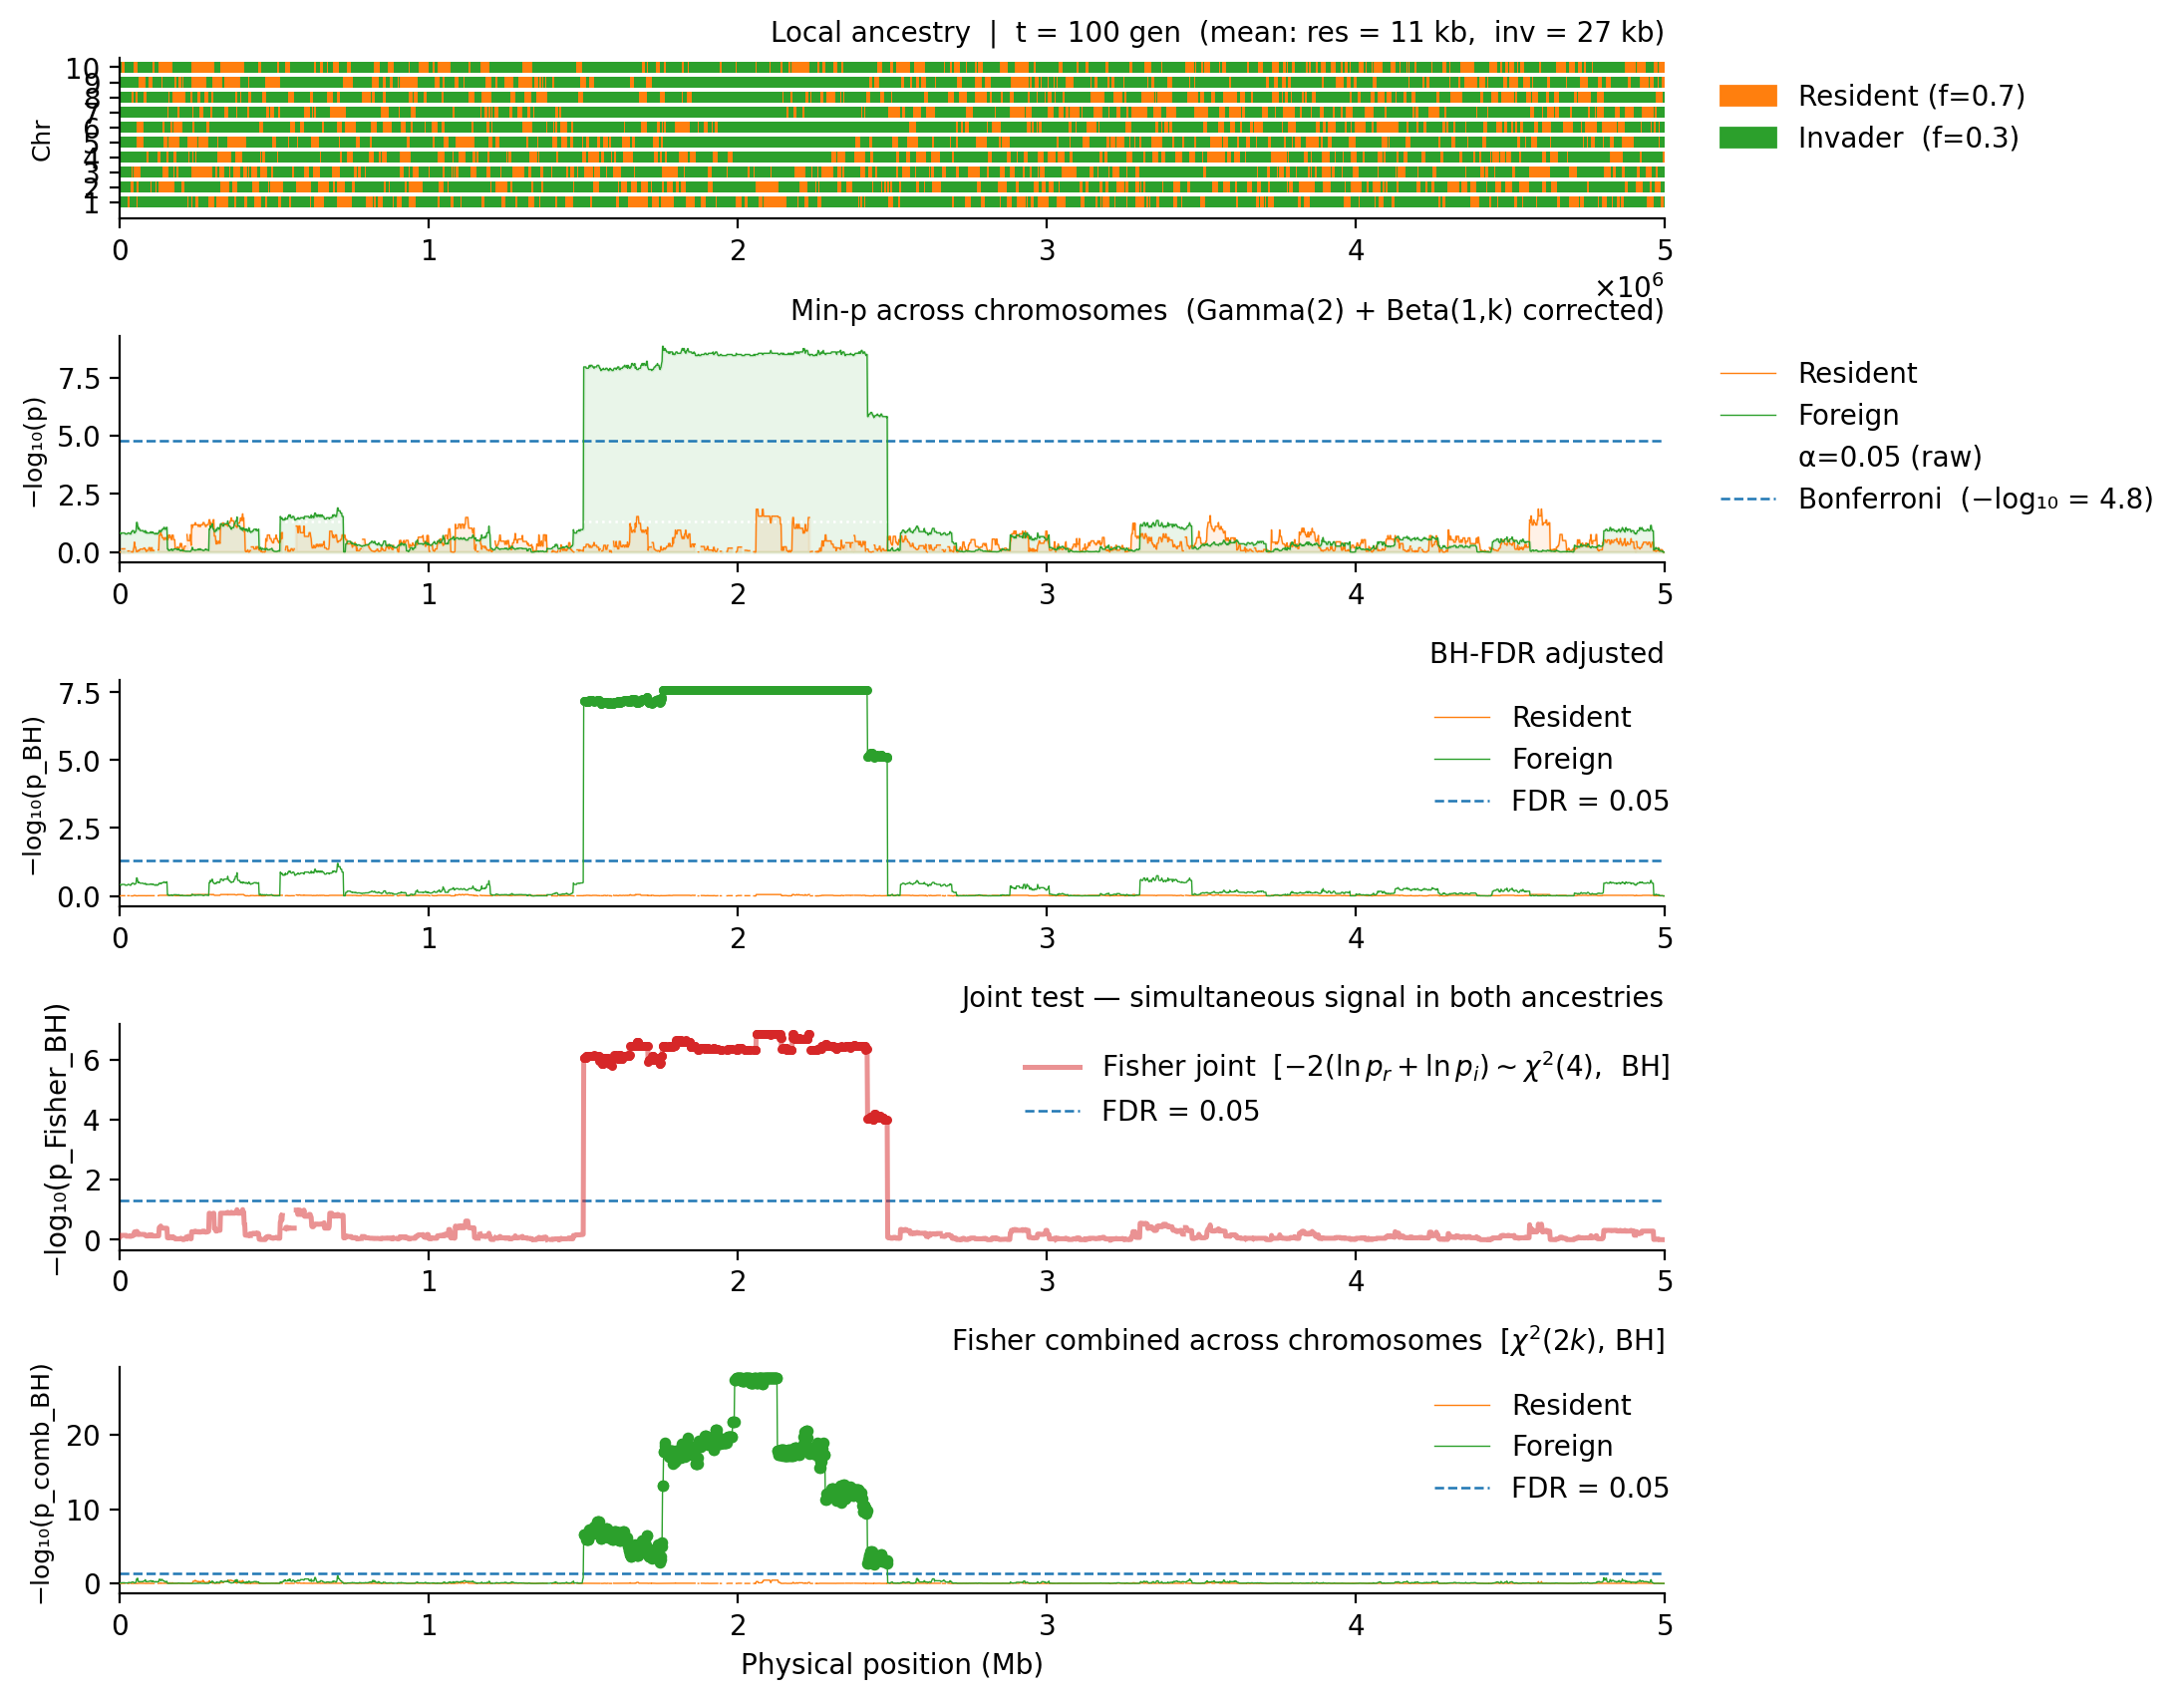

In [14]:
mb   = eval_pos / 1e6
bonf_line = -np.log10(ALPHA / N_EVAL)

fig = plt.figure(figsize=(10, 10))
gs  = gridspec.GridSpec(5, 1, hspace=0.55, height_ratios=[0.85, 1.2, 1.2, 1.2, 1.2])

# — Panel 1: chromosome diagram —
ax1 = fig.add_subplot(gs[0])
for i, ch in enumerate(chroms):
    for (s, e, anc) in ch:
        ax1.barh(i, e-s, left=s, height=0.72,
                 color=colors[anc], linewidth=0)
ax1.set_xlim(0, CHROM_LENGTH); ax1.set_ylim(-1.1, N_CHROMOSOMES - 0.4)
ax1.set_yticks(range(N_CHROMOSOMES), [str(i+1) for i in range(N_CHROMOSOMES)])
ax1.set_ylabel('Chr', fontsize=9)
patches = [mpatches.Patch(color=colors['resident'], label=f'Resident (f={F_RES})'),
           mpatches.Patch(color=colors['foreign'],  label=f'Invader  (f={F_INV})')]
ax1.legend(handles=patches, bbox_to_anchor=(1.02, 1))
ax1.set_title(
    f'Local ancestry  |  t = {T} gen  '
    f'(mean: res = {mean_res/1e3:.0f} kb,  inv = {mean_inv/1e3:.0f} kb)')

# — Panel 2: raw p-values —
ax2 = fig.add_subplot(gs[1])
for anc in ('resident', 'foreign'):
    y = -np.log10(np.maximum(pval[anc], eps))
    ax2.plot(mb, y, color=colors[anc], lw=0.5, label=anc.capitalize(), alpha=1, zorder=3)
    ax2.fill_between(mb, y, alpha=0.10, color=colors[anc])
ax2.axhline(-np.log10(ALPHA), color='white', lw=0.9, ls=':', label=f'α={ALPHA} (raw)')
ax2.axhline(bonf_line, lw=0.9, ls='--',
            label=f'Bonferroni  (−log₁₀ = {bonf_line:.1f})')
ax2.set_ylabel('−log₁₀(p)', fontsize=9)
ax2.set_title(r'Min-p across chromosomes  (Gamma(2) + Beta(1,k) corrected)')
ax2.legend(bbox_to_anchor=(1.02, 1))
ax2.set_xlim(0, CHROM_LENGTH/1e6)

# — Panel 3: BH-adjusted p-values —
ax3 = fig.add_subplot(gs[2])
for anc in ('resident', 'foreign'):
    y = -np.log10(np.maximum(pval_bh[anc], eps))
    ax3.plot(mb, y, color=colors[anc], lw=0.5, label=anc.capitalize(), zorder=3)
    sig = pval_bh[anc] < ALPHA
    if sig.any():
        ax3.scatter(mb[sig], -np.log10(np.maximum(pval_bh[anc][sig], eps)),
                    color=colors[anc], s=5, zorder=5)
ax3.axhline(-np.log10(ALPHA), lw=0.9, ls='--',
            label=f'FDR = {ALPHA}')
ax3.set_ylabel('−log₁₀(p_BH)', fontsize=9)
ax3.set_title('BH-FDR adjusted')
ax3.legend(bbox_to_anchor=(1.02, 1))
ax3.set_xlim(0, CHROM_LENGTH/1e6)

# — Panel 4: Fisher joint test (across ancestries) —
ax4 = fig.add_subplot(gs[3])
y = -np.log10(np.maximum(fp_bh, eps))
ax4.plot(mb, y, color=colors['joint'], lw=1.8,
         label=r'Fisher joint  [$-2(\ln p_r+\ln p_i)\sim\chi^2(4)$,  BH]', alpha=0.5, zorder=3)
sig_j = fp_bh < ALPHA
if sig_j.any():
    ax4.scatter(mb[sig_j], -np.log10(np.maximum(fp_bh[sig_j], eps)),
                color=colors['joint'], s=5, zorder=5)
ax4.axhline(-np.log10(ALPHA), lw=0.9, ls='--',
            label=f'FDR = {ALPHA}')
ax4.set_ylabel('−log₁₀(p_Fisher_BH)')
ax4.set_title('Joint test — simultaneous signal in both ancestries')
ax4.legend(bbox_to_anchor=(1.02, 1))
ax4.set_xlim(0, CHROM_LENGTH/1e6)

# — Panel 5: Fisher combined test across chromosomes —
ax5 = fig.add_subplot(gs[4])
for anc in ('resident', 'foreign'):
    y = -np.log10(np.maximum(pval_fisher_combined_bh[anc], eps))
    ax5.plot(mb, y, color=colors[anc], lw=0.5, label=f'{anc.capitalize()}', zorder=3)
    sig = pval_fisher_combined_bh[anc] < ALPHA
    if sig.any():
        ax5.scatter(mb[sig], -np.log10(np.maximum(pval_fisher_combined_bh[anc][sig], eps)),
                    color=colors[anc], s=10, zorder=5)
ax5.axhline(-np.log10(ALPHA), lw=0.9, ls='--',
            label=f'FDR = {ALPHA}')
ax5.set_ylabel('−log₁₀(p_comb_BH)', fontsize=9)
ax5.set_xlabel('Physical position (Mb)')
ax5.set_title(r'Fisher combined across chromosomes  [$\chi^2(2k)$, BH]')
ax5.legend(bbox_to_anchor=(1.02, 1))
ax5.set_xlim(0, CHROM_LENGTH/1e6)

plt.show()

Extremely high $-\log_{10}$ values arise when the test statistics far exceed what the null distribution can produce at any meaningful probability. The code clamps p-values at $10^{-300}$ to avoid log-of-zero errors; in practice these values simply mean "overwhelmingly significant." The validation below confirms that the tests are correctly calibrated under the null.

## Validation

A well-calibrated test produces uniformly distributed p-values when the null hypothesis is true. We verify this by running the full analysis pipeline on 200 independent simulations with no injected anomalies and checking that the histogram of raw p-values is flat, the fraction below $\alpha$ is close to $\alpha$, and the BH- and Bonferroni-corrected fractions are at or below $\alpha$. Because nearby positions share the same underlying segment, p-values are spatially correlated; a KS test on the pooled collection may therefore reject uniformity even when the marginal distribution at each position is correct. The per-simulation false positive rate is the more informative calibration metric.

In [ ]:
# ── Null simulation: validate p-value calibration ────────────────────────────
from scipy.stats import kstest

N_NULL_SIMS = 200   # number of independent null datasets
N_EVAL_VAL  = 500   # fewer positions for speed
eval_pos_val = np.linspace(0, CHROM_LENGTH, N_EVAL_VAL)

# Collect raw p-values from each simulation
null_pvals = {
    'min_p_resident': [], 'min_p_foreign': [],
    'fisher_joint': [],
    'fisher_comb_resident': [], 'fisher_comb_foreign': [],
}
# Track per-simulation false positive rates
fpr = {k: {'raw': [], 'bh': [], 'bonf': []} for k in null_pvals}

rng_null = np.random.default_rng(seed=123)

for sim in range(N_NULL_SIMS):
    null_chroms = [simulate_chromosome(CHROM_LENGTH, gen_to_phys, phys_to_gen,
                                       ancestry_rate, rng_null)
                   for _ in range(N_CHROMOSOMES)]

    res = test_segments(null_chroms, eval_pos_val, phys_to_gen, ancestry_rate, alpha=ALPHA)

    for anc in ('resident', 'foreign'):
        key = f'min_p_{anc}'
        raw = res["min_p"][anc]
        valid = ~np.isnan(raw)
        n_valid = int(valid.sum())
        null_pvals[key].extend(raw[valid].tolist())
        fpr[key]['raw'].append(np.nansum(raw < ALPHA) / max(n_valid, 1))
        fpr[key]['bonf'].append(np.nansum(res["min_p_bonf"][anc] < ALPHA) / max(n_valid, 1))
        fpr[key]['bh'].append(np.nansum(res["min_p_bh"][anc] < ALPHA) / max(n_valid, 1))

        key_fc = f'fisher_comb_{anc}'
        raw_fc = res["fisher_combined"][anc]
        valid_fc = ~np.isnan(raw_fc)
        n_valid_fc = int(valid_fc.sum())
        null_pvals[key_fc].extend(raw_fc[valid_fc].tolist())
        fpr[key_fc]['raw'].append(np.nansum(raw_fc < ALPHA) / max(n_valid_fc, 1))
        fpr[key_fc]['bh'].append(np.nansum(res["fisher_combined_bh"][anc] < ALPHA) / max(n_valid_fc, 1))

    if res["fisher_joint"] is not None:
        fp_raw = res["fisher_joint"]
        valid_j = ~np.isnan(fp_raw)
        n_valid_j = int(valid_j.sum())
        null_pvals['fisher_joint'].extend(fp_raw[valid_j].tolist())
        fpr['fisher_joint']['raw'].append(np.nansum(fp_raw < ALPHA) / max(n_valid_j, 1))
        fpr['fisher_joint']['bh'].append(np.nansum(res["fisher_joint_bh"] < ALPHA) / max(n_valid_j, 1))

print(f"Ran {N_NULL_SIMS} null simulations × {N_CHROMOSOMES} chromosomes × {N_EVAL_VAL} positions")

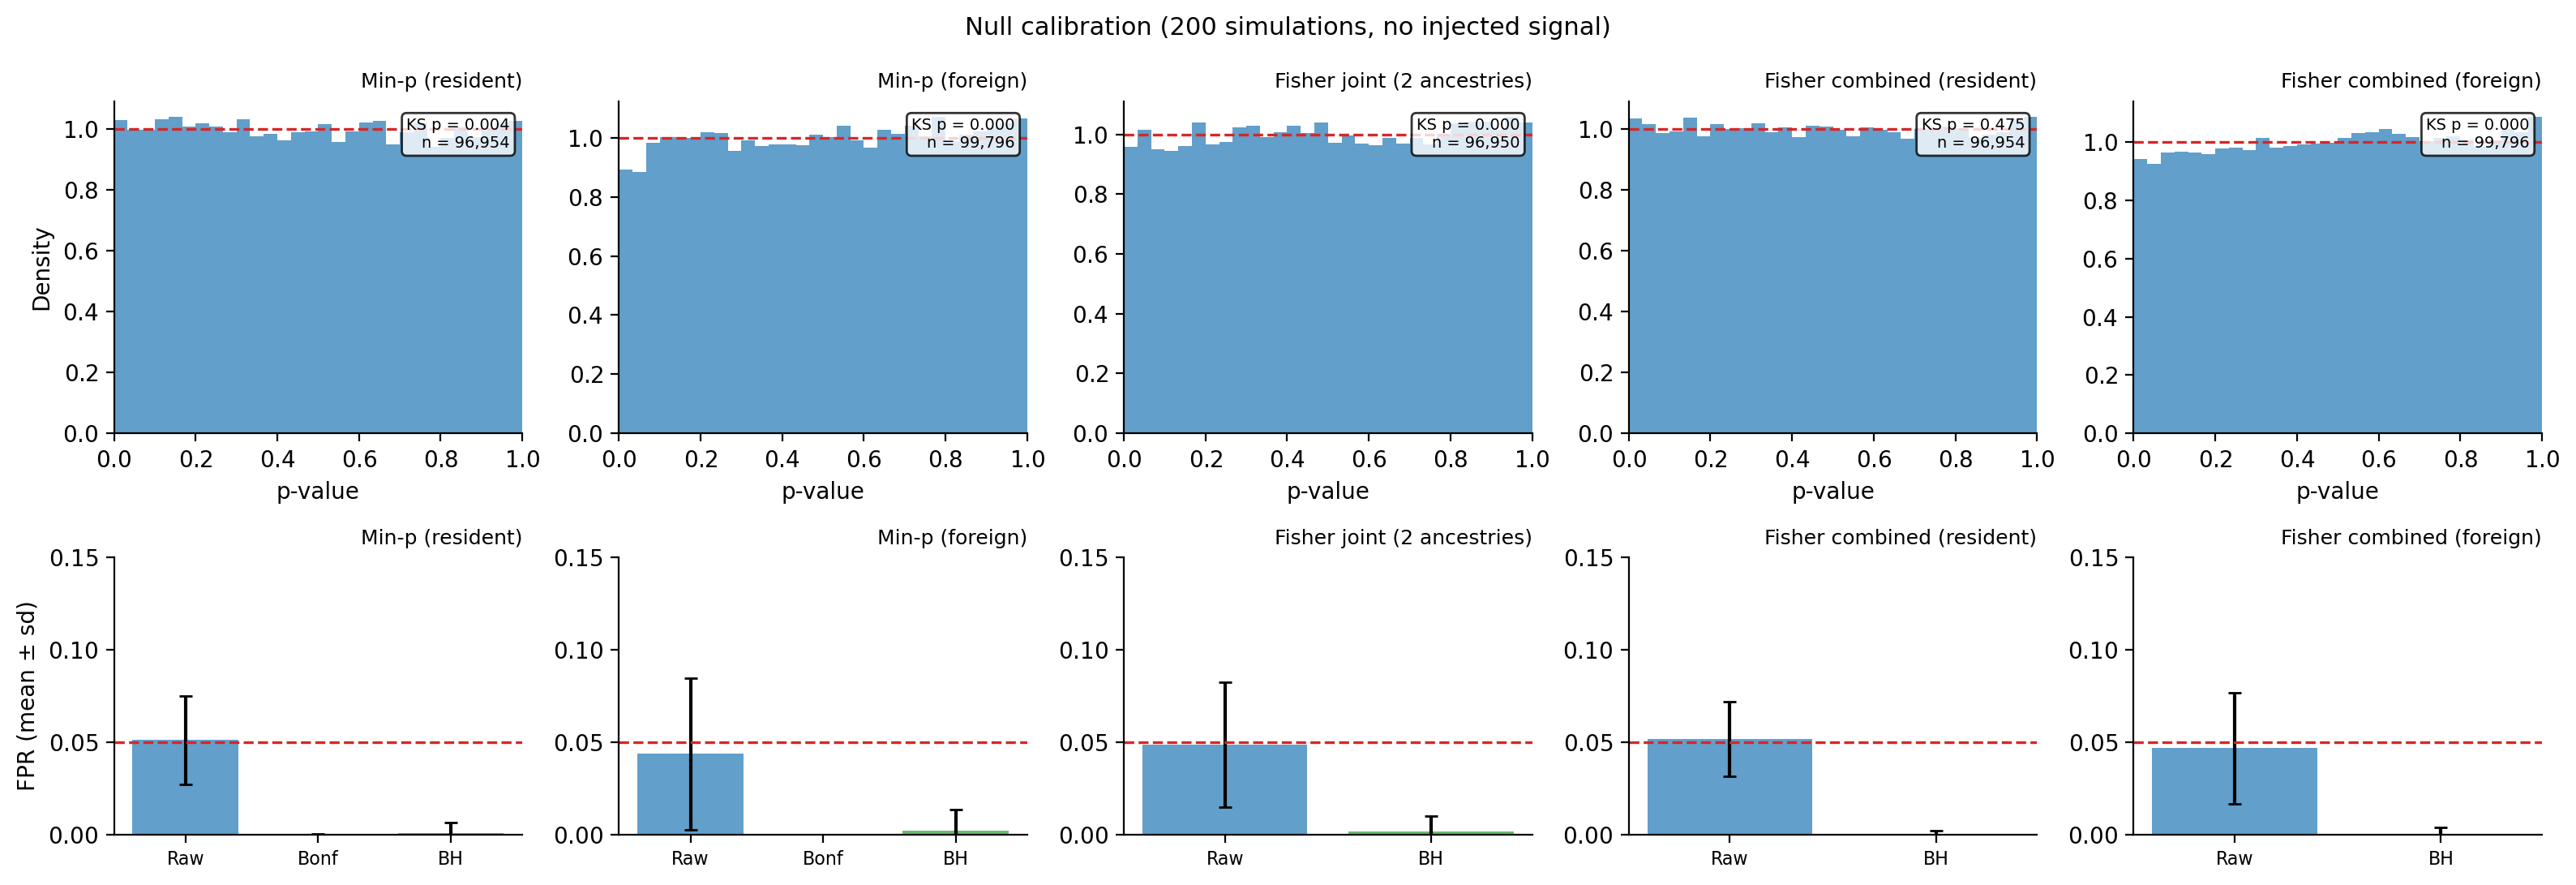

Test                              KS p    E[FPR raw]     E[FPR BH]   E[FPR Bonf]
--------------------------------------------------------------------------------
Min-p (resident)                 0.004        0.0511        0.0008        0.0000
Min-p (foreign)                  0.000        0.0435        0.0021        0.0000
Fisher joint (2 ancestries)      0.000        0.0485        0.0014           nan
Fisher combined (resident)       0.475        0.0518        0.0003           nan
Fisher combined (foreign)        0.000        0.0467        0.0003           nan

Expected: Raw FPR ≈ 0.05, BH FDR ≤ 0.05, Bonferroni FWER ≤ 0.05
KS p > 0.05 indicates p-values are consistent with Uniform[0,1].


In [16]:
# ── Plot p-value distributions and false positive rates ──────────────────────

test_labels = {
    'min_p_resident':       'Min-p (resident)',
    'min_p_foreign':        'Min-p (foreign)',
    'fisher_joint':         'Fisher joint (2 ancestries)',
    'fisher_comb_resident': 'Fisher combined (resident)',
    'fisher_comb_foreign':  'Fisher combined (foreign)',
}

n_tests = len(test_labels)
fig, axes = plt.subplots(2, n_tests, figsize=(3.2 * n_tests, 5.5),
                         gridspec_kw={'height_ratios': [1.2, 1]})

# Row 1: p-value histograms
for i, (key, label) in enumerate(test_labels.items()):
    ax = axes[0, i]
    pvals = np.array(null_pvals[key])
    ax.hist(pvals, bins=30, range=(0, 1), density=True,
            color='C0', alpha=0.7, edgecolor='none')
    ax.axhline(1.0, color='C3', ls='--', lw=1.2, label='Uniform')
    
    # KS test for uniformity
    ks_stat, ks_p = kstest(pvals, 'uniform')
    ax.set_title(label, fontsize=9)
    ax.set_xlabel('p-value')
    if i == 0:
        ax.set_ylabel('Density')
    ax.text(0.97, 0.95, f'KS p = {ks_p:.3f}\nn = {len(pvals):,}',
            transform=ax.transAxes, fontsize=7, ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    ax.set_xlim(0, 1)

# Row 2: false positive rates per simulation
for i, (key, label) in enumerate(test_labels.items()):
    ax = axes[1, i]
    rates = fpr[key]
    
    items = []
    labels_bar = []
    if rates['raw']:
        items.append(('Raw', rates['raw'], 'C0'))
        labels_bar.append('Raw')
    if rates.get('bonf') and rates['bonf']:
        items.append(('Bonf', rates['bonf'], 'C1'))
        labels_bar.append('Bonf')
    if rates['bh']:
        items.append(('BH', rates['bh'], 'C2'))
        labels_bar.append('BH')
    
    positions = np.arange(len(items))
    means = [np.mean(r[1]) for r in items]
    sds   = [np.std(r[1]) for r in items]
    colors = [r[2] for r in items]
    
    bars = ax.bar(positions, means, yerr=sds, color=colors, alpha=0.7,
                  capsize=3, edgecolor='none')
    ax.axhline(ALPHA, color='C3', ls='--', lw=1.2, label=f'α = {ALPHA}')
    ax.set_xticks(positions)
    ax.set_xticklabels([r[0] for r in items], fontsize=8)
    ax.set_ylim(0, max(ALPHA * 3, max(means) * 1.5))
    if i == 0:
        ax.set_ylabel('FPR (mean ± sd)')
    ax.set_title(label, fontsize=9)

fig.suptitle(f'Null calibration ({N_NULL_SIMS} simulations, no injected signal)', fontsize=11)
plt.tight_layout()
plt.show()

# ── Summary table ────────────────────────────────────────────────────────────
print(f"{'Test':<28s}  {'KS p':>8s}  {'E[FPR raw]':>12s}  {'E[FPR BH]':>12s}  {'E[FPR Bonf]':>12s}")
print('-' * 80)
for key, label in test_labels.items():
    pvals = np.array(null_pvals[key])
    _, ks_p = kstest(pvals, 'uniform')
    mean_raw  = np.mean(fpr[key]['raw'])  if fpr[key]['raw']  else float('nan')
    mean_bh   = np.mean(fpr[key]['bh'])   if fpr[key]['bh']   else float('nan')
    mean_bonf = np.mean(fpr[key]['bonf']) if fpr[key].get('bonf') and fpr[key]['bonf'] else float('nan')
    print(f"{label:<28s}  {ks_p:>8.3f}  {mean_raw:>12.4f}  {mean_bh:>12.4f}  {mean_bonf:>12.4f}")
print()
print(f"Expected: Raw FPR ≈ {ALPHA}, BH FDR ≤ {ALPHA}, Bonferroni FWER ≤ {ALPHA}")
print("KS p > 0.05 indicates p-values are consistent with Uniform[0,1].")

---

## Summary

The table below shows the expected tract lengths and the Bonferroni significance thresholds for each ancestry class, expressed in both genetic and physical distance. The rate parameter is $\lambda = (1-f) \cdot t$, where a tract of ancestry with frequency $f$ ends when recombination hits the other ancestry's background (probability $1-f$).

In [ ]:
# ── Threshold summary table ──────────────────────────────────────────────────
rows = []
for label, f in [('Resident', F_RES), ('Invader', F_INV)]:
    lam     = (1 - f) * T                    # rate in genetic distance
    mean_g  = 1 / lam                        # Morgans
    mean_bp = mean_g / r
    # Bonferroni threshold: (1 + λg) exp(-λg) < α/N
    # Approximate: for large λg, dominated by exp(-λg), so g_bonf ≈ -ln(α/N) / λ
    g_bonf  = -np.log(ALPHA / N_EVAL) / lam
    bp_bonf = g_bonf / r
    rows.append({
        'Ancestry'              : label,
        'f'                     : f,
        'Rate λ = (1-f)·t'     : f'{lam:.1f}  M⁻¹',
        'Mean tract (cM)'       : f'{mean_g*100:.3f}',
        'Mean tract (kb)'       : f'{mean_bp/1e3:.0f}',
        'Bonferroni thr. (cM)'  : f'{g_bonf*100:.3f}',
        'Bonferroni thr. (kb)'  : f'{bp_bonf/1e3:.0f}',
        'Bonferroni / mean'     : f'{g_bonf/mean_g:.1f}×',
    })

df = pd.DataFrame(rows).set_index('Ancestry')
df